# 0. Download dataset & Import libraries

In [ ]:
!pip install -q unidecode tokenizers evaluate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def set_seed(seed=42):
	random.seed(seed)
	os.environ['PYTHONHASHSEED'] = str(seed)
	np.random.seed(seed)

	torch.manual_seed(seed)

	if torch.backends.mps.is_available():
		torch.mps.manual_seed(seed)
		os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

	if torch.cuda.is_available():
		torch.cuda.manual_seed(seed)
		torch.cuda.manual_seed_all(seed)
		torch.backends.cudnn.deterministic = True
		torch.backends.cudnn.benchmark = False

	try:
		torch.use_deterministic_algorithms(True)
	except RuntimeError:
		pass
set_seed()

In [ ]:
!gdown 1o09HEkDBBEjsW3gN76vDYfCAKiCqpcpg
!unzip /content/financial_sentiment.zip
!rm -rf /content/financial_sentiment.zip

Downloading...
From: https://drive.google.com/uc?id=1o09HEkDBBEjsW3gN76vDYfCAKiCqpcpg
To: /content/financial_sentiment.zip
100% 925k/925k [00:00<00:00, 50.8MB/s]
Archive:  /content/financial_sentiment.zip
  inflating: FinancialPhraseBank/License.txt  
  inflating: FinancialPhraseBank/README.txt  
  inflating: FinancialPhraseBank/Sentences_50Agree.txt  
  inflating: FinancialPhraseBank/Sentences_66Agree.txt  
  inflating: FinancialPhraseBank/Sentences_75Agree.txt  
  inflating: FinancialPhraseBank/Sentences_AllAgree.txt  
  inflating: all-data.csv            


In [ ]:
data_path = '/content/all-data.csv'
headers = ['sentiment', 'content']

df = pd.read_csv(
  data_path,
  names=headers,
  encoding='ISO-8859-1'
)
df

,sentiment,content
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...
...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...
4844,negative,Net sales of the Paper segment decreased to EU...


In [ ]:
classes_lst = df['sentiment'].unique()
n_classes = len(classes_lst)
classes_lst

array(['neutral', 'negative', 'positive'], dtype=object)

In [ ]:
label2id = {
    class_name: idx
    for idx, class_name in enumerate(classes_lst)
}

id2label = {
    idx: class_name
    for idx, class_name in enumerate(classes_lst)
}

In [ ]:
label2id

{'neutral': 0, 'negative': 1, 'positive': 2}

In [ ]:
df['sentiment'] = df['sentiment'].apply(lambda x: label2id[x])

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['sentiment']
 )
val_df, test_df = train_test_split(
    temp_df,
    test_size=1/3,
    random_state=42,
    stratify=temp_df['sentiment']
 )

# 1. RNN-based model

## 1.1. Build tokenizer

In [ ]:
import os
from tokenizers import Tokenizer, models, trainers, pre_tokenizers
from transformers import PreTrainedTokenizerFast, AutoTokenizer

tokenizer_dir = './financial_word_tokenizer'
os.makedirs(tokenizer_dir, exist_ok=True)

word_tokenizer = Tokenizer(models.WordLevel(unk_token='<unk>'))
word_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
word_trainer = trainers.WordLevelTrainer(
    vocab_size=20000,
    min_frequency=3,
    special_tokens=['<pad>', '<unk>']
)

word_tokenizer.train_from_iterator(df['content'].tolist(), trainer=word_trainer)
word_tokenizer.save(f'{tokenizer_dir}/tokenizer.json')

hf_fast_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=f'{tokenizer_dir}/tokenizer.json',
    unk_token='<unk>',
    pad_token='<pad>'
)
hf_fast_tokenizer.save_pretrained(tokenizer_dir)

tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir, use_fast=True)
vocab_size = tokenizer.vocab_size
pad_token_id = tokenizer.pad_token_id

## 1.2. Transform dataset for training

In [ ]:
def transform(text, tokenizer, max_seq_len):
    encoded = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_seq_len,
        add_special_tokens=False,
        return_attention_mask=False
    )
    return encoded['input_ids']

In [ ]:
from torch.utils.data import Dataset

class FinancialNews(Dataset):
    def __init__(self, X, y, tokenizer, max_seq_len, transform=None):
        self.texts = X
        self.labels = y
        self.tokenizer = tokenizer
        self.max_seq_len = max_seq_len
        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        if self.transform:
            text = self.transform(text, self.tokenizer, self.max_seq_len)
        text = torch.tensor(text, dtype=torch.long)

        return text, torch.tensor(label, dtype=torch.long)

In [ ]:
max_seq_len = 32

train_dataset = FinancialNews(
    train_df['content'].tolist(),
    train_df['sentiment'].tolist(),
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    transform=transform
)
val_dataset = FinancialNews(
    val_df['content'].tolist(),
    val_df['sentiment'].tolist(),
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    transform=transform
)
test_dataset = FinancialNews(
    test_df['content'].tolist(),
    test_df['sentiment'].tolist(),
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    transform=transform
)

In [ ]:
print(f'Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}')

print('Class distribution by split:')
print('Train:\n', train_df['sentiment'].value_counts(normalize=True).sort_index())
print('Val:\n', val_df['sentiment'].value_counts(normalize=True).sort_index())
print('Test:\n', test_df['sentiment'].value_counts(normalize=True).sort_index())

Train size: 3392, Val size: 969, Test size: 485
Class distribution by split:
Train:
 sentiment
0    0.594045
1    0.124705
2    0.281250
Name: proportion, dtype: float64
Val:
 sentiment
0    0.594427
1    0.124871
2    0.280702
Name: proportion, dtype: float64
Test:
 sentiment
0    0.593814
1    0.123711
2    0.282474
Name: proportion, dtype: float64


## 1.3. Model

In [ ]:
import evaluate
import os
from pathlib import Path
from torch.utils.data import Dataset
from transformers import TrainingArguments, Trainer

class TrainerDataset(Dataset):
    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        input_ids, label = self.subset[idx]
        return {'input_ids': input_ids.long(), 'labels': label.long()}

accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

def save_local_checkpoint(model, model_name, base_dir='./saved_models', tokenizer=None):
    """Save model locally for later inference without pushing to Hub."""
    save_dir = Path(base_dir) / model_name
    save_dir.mkdir(parents=True, exist_ok=True)

    # Hugging Face models (e.g., DistilBERT)
    if hasattr(model, 'save_pretrained'):
        model.save_pretrained(save_dir)
        if tokenizer is not None and hasattr(tokenizer, 'save_pretrained'):
            tokenizer.save_pretrained(save_dir)
        print(f'Saved Hugging Face model to: {save_dir.resolve()}')
        return str(save_dir)

    # PyTorch custom models (RNN/LSTM/GRU/BiLSTM...)
    torch.save(model.state_dict(), save_dir / 'model_state_dict.pt')
    print(f'Saved PyTorch state_dict to: {(save_dir / "model_state_dict.pt").resolve()}')
    return str(save_dir)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### 1.3.1. RNN

In [ ]:
class SentimentClassifierRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, n_layers, n_classes, dropout_prob, fc_dim):
        super(SentimentClassifierRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_token_id)
        self.rnn = nn.RNN(embedding_dim, hidden_size, n_layers, batch_first=True)
        self.norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc1 = nn.Linear(hidden_size, fc_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_dim, n_classes)

    def forward(self, input_ids=None, labels=None):
        x = self.embedding(input_ids)
        x, _ = self.rnn(x)
        x = x[:, -1, :]
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        logits = self.fc2(x)

        loss = None
        if labels is not None:
            loss = nn.functional.cross_entropy(logits, labels)

        return {'loss': loss, 'logits': logits}

In [ ]:
embedding_dim = 64
hidden_size = 128
n_layers = 2
dropout_prob = 0.2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = SentimentClassifierRNN(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    n_layers=n_layers,
    n_classes=n_classes,
    dropout_prob=dropout_prob,
    fc_dim=32
).to(device)

In [ ]:
lr = 1e-4
epochs = 100

training_args = TrainingArguments(
    output_dir='./rnn_trainer_results',
    learning_rate=lr,
    optim='adamw_torch',
    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,
    num_train_epochs=epochs,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    logging_first_step=True,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=TrainerDataset(train_dataset),
    eval_dataset=TrainerDataset(val_dataset),
    compute_metrics=compute_metrics,
)

In [ ]:
train_result = trainer.train()
# Save RNN model
save_local_checkpoint(model, 'rnn_model')

Epoch,Training Loss,Validation Loss,Accuracy
1,1.044772,0.950782,0.575851
2,0.926732,0.929288,0.585139
3,0.919180,0.926550,0.591331
4,0.912776,0.924382,0.592363
5,0.908189,0.922577,0.592363
6,0.905428,0.921346,0.592363
7,0.896981,0.921971,0.593395
8,0.892800,0.919806,0.587203
9,0.884283,0.918085,0.587203
10,0.879003,0.916059,0.588235


Saved PyTorch state_dict to: /content/saved_models/rnn_model/model_state_dict.pt


'saved_models/rnn_model'

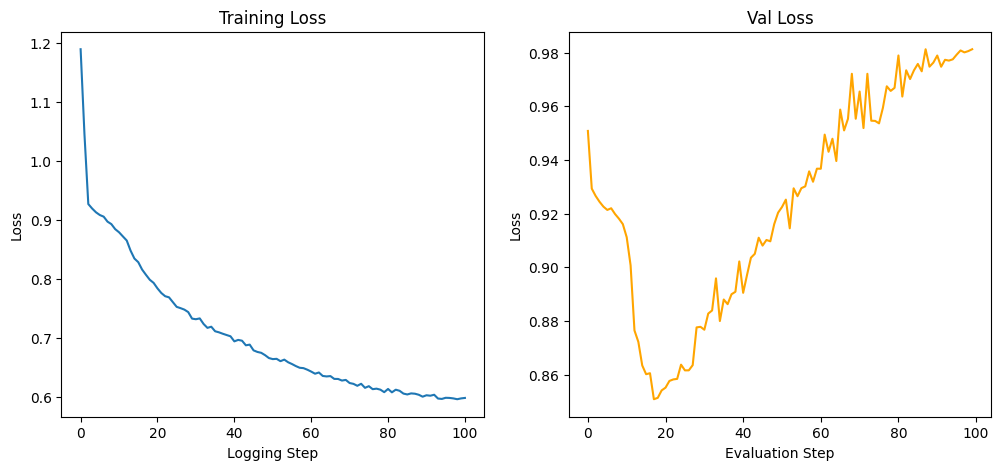

In [ ]:
history = trainer.state.log_history
train_losses = [entry['loss'] for entry in history if 'loss' in entry]
val_losses = [entry['eval_loss'] for entry in history if 'eval_loss' in entry]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Logging Step')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Evaluation Step')
ax[1].set_ylabel('Loss')
plt.show()

In [ ]:
val_results = trainer.evaluate(eval_dataset=TrainerDataset(val_dataset))
test_results = trainer.evaluate(eval_dataset=TrainerDataset(test_dataset))

print('Evaluation on val/test dataset')
print('Val accuracy: ', val_results['eval_accuracy'])
print('Test accuracy: ', test_results['eval_accuracy'])

Evaluation on val/test dataset
Val accuracy:  0.6274509803921569
Test accuracy:  0.6082474226804123


### 1.3.2. LSTM

In [ ]:
class SentimentClassifierLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, n_layers, n_classes, dropout_prob, fc_dim):
        super(SentimentClassifierLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_token_id)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, n_layers, batch_first=True)
        self.norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc1 = nn.Linear(hidden_size, fc_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_dim, n_classes)

    def forward(self, input_ids=None, labels=None):
        x = self.embedding(input_ids)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        logits = self.fc2(x)

        loss = None
        if labels is not None:
            loss = nn.functional.cross_entropy(logits, labels)

        return {'loss': loss, 'logits': logits}

In [ ]:
embedding_dim = 64
hidden_size = 128
n_layers = 2
dropout_prob = 0.2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = SentimentClassifierLSTM(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    n_layers=n_layers,
    n_classes=n_classes,
    dropout_prob=dropout_prob,
    fc_dim=32
).to(device)

In [ ]:
lr = 1e-4
epochs = 100

training_args = TrainingArguments(
    output_dir='./lstm_trainer_results',
    learning_rate=lr,
    optim='adamw_torch',
    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,
    num_train_epochs=epochs,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    logging_first_step=True,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=TrainerDataset(train_dataset),
    eval_dataset=TrainerDataset(val_dataset),
    compute_metrics=compute_metrics,
)

In [ ]:
train_result = trainer.train()
# Save LSTM model
save_local_checkpoint(model, 'lstm_model')

Epoch,Training Loss,Validation Loss,Accuracy
1,1.011296,0.927714,0.594427
2,0.923554,0.915399,0.594427
3,0.914843,0.908408,0.596491
4,0.907198,0.900432,0.602683
5,0.896906,0.893618,0.605779
6,0.891596,0.886178,0.615067
7,0.880455,0.881972,0.615067
8,0.871382,0.871580,0.611971
9,0.860365,0.860076,0.614035
10,0.847919,0.845321,0.623323


Saved PyTorch state_dict to: /content/saved_models/lstm_model/model_state_dict.pt


'saved_models/lstm_model'

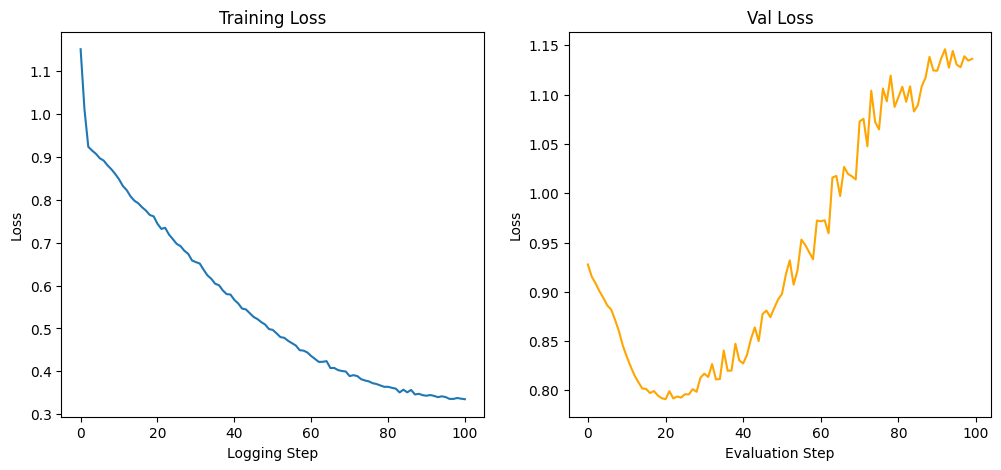

In [ ]:
history = trainer.state.log_history
train_losses = [entry['loss'] for entry in history if 'loss' in entry]
val_losses = [entry['eval_loss'] for entry in history if 'eval_loss' in entry]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Logging Step')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Evaluation Step')
ax[1].set_ylabel('Loss')
plt.show()

In [ ]:
val_results = trainer.evaluate(eval_dataset=TrainerDataset(val_dataset))
test_results = trainer.evaluate(eval_dataset=TrainerDataset(test_dataset))

print('Evaluation on val/test dataset')
print('Val accuracy: ', val_results['eval_accuracy'])
print('Test accuracy: ', test_results['eval_accuracy'])

Evaluation on val/test dataset
Val accuracy:  0.6800825593395253
Test accuracy:  0.6391752577319587


### 1.3.3. GRU

In [ ]:
class SentimentClassifierBiGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, n_layers, n_classes, dropout_prob, fc_dim):
        super(SentimentClassifierBiGRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_token_id)
        self.gru = nn.GRU(embedding_dim, hidden_size, n_layers, batch_first=True)
        self.norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc1 = nn.Linear(hidden_size, fc_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_dim, n_classes)

    def forward(self, input_ids=None, labels=None):
        x = self.embedding(input_ids)
        x, _ = self.gru(x)
        x = x[:, -1, :]
        x = self.norm(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        logits = self.fc2(x)

        loss = None
        if labels is not None:
            loss = nn.functional.cross_entropy(logits, labels)

        return {'loss': loss, 'logits': logits}

In [ ]:
embedding_dim = 64
hidden_size = 128
n_layers = 2
dropout_prob = 0.2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = SentimentClassifierBiGRU(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    n_layers=n_layers,
    n_classes=n_classes,
    dropout_prob=dropout_prob,
    fc_dim=32
).to(device)

In [ ]:
lr = 1e-4
epochs = 100

training_args = TrainingArguments(
    output_dir='./gru_trainer_results',
    learning_rate=lr,
    optim='adamw_torch',
    per_device_train_batch_size=128,
    per_device_eval_batch_size=8,
    num_train_epochs=epochs,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    logging_first_step=True,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=TrainerDataset(train_dataset),
    eval_dataset=TrainerDataset(val_dataset),
    compute_metrics=compute_metrics,
)

In [ ]:
train_result = trainer.train()
# Save GRU model
save_local_checkpoint(model, 'gru_model')

Epoch,Training Loss,Validation Loss,Accuracy
1,0.955179,0.920730,0.595459
2,0.916566,0.909815,0.598555
3,0.913148,0.907246,0.600619
4,0.906070,0.900424,0.603715
5,0.899645,0.897262,0.604747
6,0.892913,0.891344,0.606811
7,0.885557,0.889665,0.609907
8,0.882230,0.880678,0.605779
9,0.868481,0.872611,0.606811
10,0.865178,0.866849,0.615067


Saved PyTorch state_dict to: /content/saved_models/gru_model/model_state_dict.pt


'saved_models/gru_model'

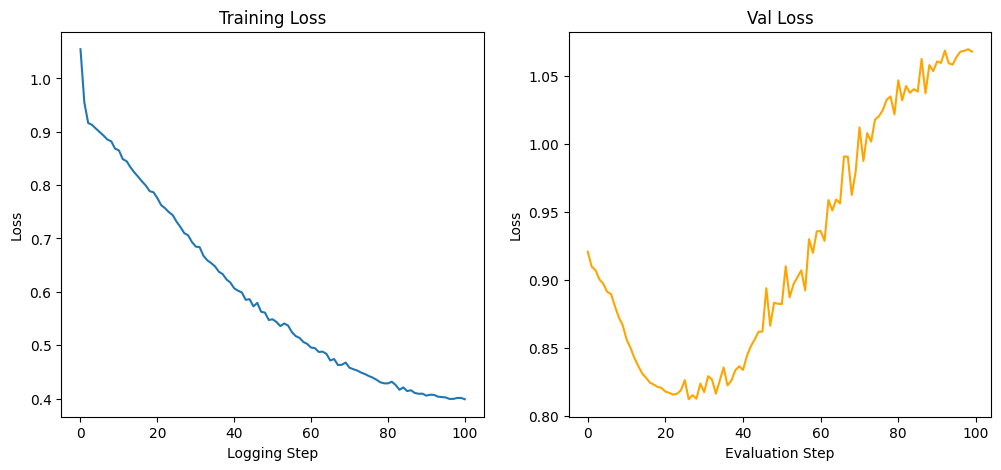

In [ ]:
history = trainer.state.log_history
train_losses = [entry['loss'] for entry in history if 'loss' in entry]
val_losses = [entry['eval_loss'] for entry in history if 'eval_loss' in entry]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Logging Step')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Evaluation Step')
ax[1].set_ylabel('Loss')
plt.show()

In [ ]:
val_results = trainer.evaluate(eval_dataset=TrainerDataset(val_dataset))
test_results = trainer.evaluate(eval_dataset=TrainerDataset(test_dataset))

print('Evaluation on val/test dataset')
print('Val accuracy: ', val_results['eval_accuracy'])
print('Test accuracy: ', test_results['eval_accuracy'])

Evaluation on val/test dataset
Val accuracy:  0.6676986584107327
Test accuracy:  0.6494845360824743


# 3. Transformer-based model

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=n_classes)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Reuse exactly the same split as RNN/LSTM/GRU/BiLSTM
train_bert_dataset = BERTDataset(
    texts=train_df['content'].to_list(),
    labels=train_df['sentiment'].to_list(),
    tokenizer=tokenizer
)

val_bert_dataset = BERTDataset(
    texts=val_df['content'].to_list(),
    labels=val_df['sentiment'].to_list(),
    tokenizer=tokenizer
)

test_bert_dataset = BERTDataset(
    texts=test_df['content'].to_list(),
    labels=test_df['sentiment'].to_list(),
    tokenizer=tokenizer
)

In [ ]:
training_args = TrainingArguments(
    output_dir='./distilbert_trainer_results',
    learning_rate=5e-5,
    optim='adamw_torch',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    logging_first_step=True,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_bert_dataset,
    eval_dataset=val_bert_dataset,
    compute_metrics=compute_metrics,
)

In [ ]:
train_result = trainer.train()
# Save DistilBERT model
save_local_checkpoint(model, 'distilbert_model', tokenizer=tokenizer)

Epoch,Training Loss,Validation Loss,Accuracy
1,0.525390,0.358883,0.846233
2,0.241243,0.375425,0.850361
3,0.109902,0.479791,0.858617


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Hugging Face model to: /content/saved_models/distilbert_model


'saved_models/distilbert_model'

In [ ]:
val_results = trainer.evaluate(eval_dataset=val_bert_dataset)
test_results = trainer.evaluate(eval_dataset=test_bert_dataset)

print('Evaluation on val/test dataset')
print('Val accuracy: ', val_results['eval_accuracy'])
print('Test accuracy: ', test_results['eval_accuracy'])

Evaluation on val/test dataset
Val accuracy:  0.8586171310629515
Test accuracy:  0.8247422680412371
